# Phân loại bình luận độc hại tiếng Việt

## Thư viện

In [ ]:
# import thu vien
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
import subprocess
import sys
import json
from pathlib import Path

from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

try:
    from pyvi import ViTokenizer
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "pyvi"])
    from pyvi import ViTokenizer


## Tải dữ liệu

In [ ]:
# doc du lieu
BASE_DIR = str(PROJECT_ROOT)
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "outputs", "models")
METRIC_DIR = os.path.join(BASE_DIR, "outputs", "results")
FIGURE_DIR = os.path.join(BASE_DIR, "outputs", "figures")

TEXT_COL = "text_clean"
LABEL_COL = "label_id"
LABEL_MAP = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}

test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test_processed.csv"))

svm_metric_df = pd.read_csv(os.path.join(METRIC_DIR, "svm_metrics.csv"))
bilstm_metric_df = pd.read_csv(os.path.join(METRIC_DIR, "bilstm_metrics.csv"))
phobert_metric_df = pd.read_csv(os.path.join(METRIC_DIR, "phobert_metrics.csv"))

test_df.shape


(6680, 5)

## So sánh mô hình

In [ ]:
# tong hop metric

# them ten model
phobert_metric_df["model"] = "PhoBERT"

compare_df = pd.concat(
    [
        svm_metric_df[["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]],
        bilstm_metric_df[["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]],
        phobert_metric_df[["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]],
    ],
    ignore_index=True
)

compare_df["model"] = compare_df["model"].replace({
    "TF-IDF + SVM": "SVM",
    "BiLSTM": "BiLSTM",
    "PhoBERT-base": "PhoBERT",
    "PhoBERT": "PhoBERT"
})

compare_df = compare_df.drop_duplicates(subset=["model"]).copy()
compare_df = compare_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)
compare_df.round(4)


,model,accuracy,precision_macro,recall_macro,f1_macro
0,PhoBERT,0.8599,0.6468,0.6943,0.6671
1,SVM,0.8632,0.6522,0.6347,0.6427
2,BiLSTM,0.8253,0.5875,0.6548,0.6147


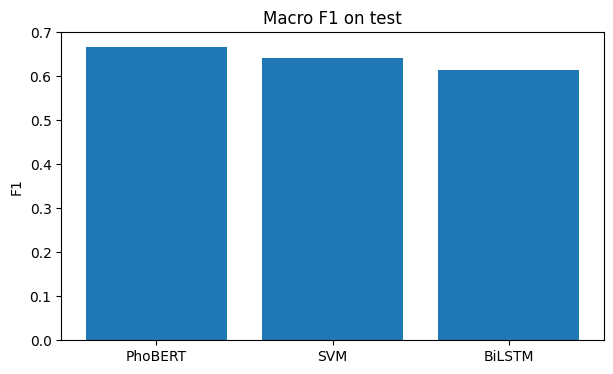

In [5]:
# ve macro f1
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(compare_df["model"], compare_df["f1_macro"])
ax.set_title("Macro F1 on test")
ax.set_ylabel("F1")
os.makedirs(FIGURE_DIR, exist_ok=True)
fig.savefig(os.path.join(FIGURE_DIR, "model_comparison_f1.png"), dpi=300, bbox_inches="tight")
plt.show()


In [6]:
# luu bang tong hop
compare_df.to_csv(os.path.join(METRIC_DIR, "model_comparison.csv"), index=False)

## Tái dự đoán

In [7]:
# svm
svm_vectorizer = joblib.load(os.path.join(MODEL_DIR, "tfidf_vectorizer.joblib"))
svm_model = joblib.load(os.path.join(MODEL_DIR, "svm_model.joblib"))

svm_pred = svm_model.predict(svm_vectorizer.transform(test_df[TEXT_COL].fillna("").astype(str)))
len(svm_pred)

6680

In [8]:
# bilstm
def segment_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text.strip().lower())
    return ViTokenizer.tokenize(text)

def tokenize_text(text):
    return str(text).split()

def encode_text(text, vocab, max_len):
    tokens = tokenize_text(text)[:max_len]
    ids = [vocab.get(token, 1) for token in tokens]

    if len(ids) == 0:
        ids = [1]

    length = len(ids)

    if length < max_len:
        ids += [0] * (max_len - length)

    return ids, length

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, length = encode_text(self.texts[idx], self.vocab, self.max_len)
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.emb_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 4, num_classes)

    def forward(self, input_ids, lengths):
        emb = self.emb_dropout(self.embedding(input_ids))

        packed = nn.utils.rnn.pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=input_ids.size(1)
        )

        mask = (input_ids != 0).unsqueeze(-1)
        output_masked = output.masked_fill(~mask, -1e9)
        max_pool = output_masked.max(dim=1).values

        sum_pool = (output * mask).sum(dim=1)
        valid_len = mask.sum(dim=1).clamp(min=1)
        mean_pool = sum_pool / valid_len

        feat = torch.cat([max_pool, mean_pool], dim=1)
        logits = self.fc(self.dropout(feat))
        return logits

with open(os.path.join(MODEL_DIR, "bilstm_vocab.json"), "r", encoding="utf-8") as f:
    bilstm_vocab = json.load(f)

bilstm_info = bilstm_metric_df.iloc[0].to_dict()
bilstm_max_len = int(bilstm_info["max_len"])
bilstm_embed_dim = int(bilstm_info["embed_dim"])
bilstm_hidden_dim = int(bilstm_info["hidden_dim"])
bilstm_num_layers = int(bilstm_info["num_layers"])

bilstm_test_df = test_df.copy()
bilstm_test_df["text_seg"] = bilstm_test_df[TEXT_COL].fillna("").apply(segment_text)

bilstm_test_dataset = TextDataset(
    bilstm_test_df["text_seg"],
    bilstm_test_df[LABEL_COL],
    bilstm_vocab,
    bilstm_max_len
)

bilstm_test_loader = DataLoader(bilstm_test_dataset, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bilstm_model = BiLSTMClassifier(
    vocab_size=len(bilstm_vocab),
    embed_dim=bilstm_embed_dim,
    hidden_dim=bilstm_hidden_dim,
    num_classes=3,
    num_layers=bilstm_num_layers,
    dropout=0.4
).to(device)

bilstm_model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "bilstm_best.pt"), map_location=device))
bilstm_model.eval()

bilstm_pred = []

with torch.no_grad():
    for batch in bilstm_test_loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        logits = bilstm_model(input_ids, lengths)
        bilstm_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

len(bilstm_pred)

6680

In [9]:
# phobert
phobert_pred_path = os.path.join(METRIC_DIR, "phobert_test_predictions.csv")
assert os.path.exists(phobert_pred_path), "Can chay file 4 truoc"

phobert_pred_df = pd.read_csv(phobert_pred_path)
phobert_pred = phobert_pred_df["pred_id"].astype(int).tolist()

len(phobert_pred)

6680

## Phân tích lỗi

In [10]:
# ghep ket qua
result_df = test_df[[TEXT_COL, LABEL_COL, "label_name"]].copy()
result_df["svm_pred"] = svm_pred
result_df["bilstm_pred"] = bilstm_pred
result_df["phobert_pred"] = phobert_pred

result_df["svm_label"] = result_df["svm_pred"].map(LABEL_MAP)
result_df["bilstm_label"] = result_df["bilstm_pred"].map(LABEL_MAP)
result_df["phobert_label"] = result_df["phobert_pred"].map(LABEL_MAP)

result_df["svm_ok"] = (result_df["svm_pred"] == result_df[LABEL_COL]).astype(int)
result_df["bilstm_ok"] = (result_df["bilstm_pred"] == result_df[LABEL_COL]).astype(int)
result_df["phobert_ok"] = (result_df["phobert_pred"] == result_df[LABEL_COL]).astype(int)

result_df.head()

,text_clean,label_id,label_name,svm_pred,bilstm_pred,phobert_pred,svm_label,bilstm_label,phobert_label,svm_ok,bilstm_ok,phobert_ok
0,Đừng cố biện minh =)))) choi lon,0,CLEAN,2,1,1,HATE,OFFENSIVE,OFFENSIVE,0,0,0
1,Haizz. Nthe này thì dân khổ quá,1,OFFENSIVE,0,0,1,CLEAN,CLEAN,OFFENSIVE,0,0,1
2,the nay ma chi phat gay roi trat tu cong cong ...,0,CLEAN,2,0,0,HATE,CLEAN,CLEAN,0,1,1
3,Mua cho em hộp bcs mĩ sài cho oai :)),0,CLEAN,0,0,0,CLEAN,CLEAN,CLEAN,1,1,1
4,coin card :3,1,OFFENSIVE,0,0,0,CLEAN,CLEAN,CLEAN,0,0,0


In [11]:
# bao cao tung mo hinh
def make_report(y_true, y_pred):
    return pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            target_names=["CLEAN", "OFFENSIVE", "HATE"],
            output_dict=True,
            zero_division=0
        )
    ).T

svm_report_df = make_report(result_df[LABEL_COL], result_df["svm_pred"])
bilstm_report_df = make_report(result_df[LABEL_COL], result_df["bilstm_pred"])
phobert_report_df = make_report(result_df[LABEL_COL], result_df["phobert_pred"])

phobert_report_df.round(4)

,precision,recall,f1-score,support
CLEAN,0.9475,0.9135,0.9302,5548.0000
OFFENSIVE,0.3980,0.5270,0.4535,444.0000
HATE,0.5949,0.6424,0.6177,688.0000
accuracy,0.8599,0.8599,0.8599,0.8599
macro avg,0.6468,0.6943,0.6671,6680.0000
weighted avg,0.8746,0.8599,0.8663,6680.0000


In [12]:
# loi cua phobert
phobert_error_df = result_df[result_df["phobert_ok"] == 0].copy()
phobert_error_df["error_pair"] = phobert_error_df["label_name"] + " -> " + phobert_error_df["phobert_label"]

phobert_error_df["error_pair"].value_counts().rename_axis("error_pair").reset_index(name="count")

,error_pair,count
0,CLEAN -> OFFENSIVE,254
1,CLEAN -> HATE,226
2,HATE -> CLEAN,146
3,OFFENSIVE -> CLEAN,135
4,HATE -> OFFENSIVE,100
5,OFFENSIVE -> HATE,75


In [13]:
# phobert dung, model khac sai
better_df = result_df[
    (result_df["phobert_ok"] == 1) &
    ((result_df["svm_ok"] == 0) | (result_df["bilstm_ok"] == 0))
].copy()

better_df[["label_name", TEXT_COL, "svm_label", "bilstm_label", "phobert_label"]].head(15)

,label_name,text_clean,svm_label,bilstm_label,phobert_label
1,OFFENSIVE,Haizz. Nthe này thì dân khổ quá,CLEAN,CLEAN,OFFENSIVE
2,CLEAN,the nay ma chi phat gay roi trat tu cong cong ...,HATE,CLEAN,CLEAN
10,CLEAN,À thì ra người Nhật cũng chẳng hợn Võ Hồng Tâm,CLEAN,OFFENSIVE,CLEAN
19,CLEAN,Sét đánh chết tao đi,CLEAN,OFFENSIVE,CLEAN
23,HATE,"Đề nghị 17, 22,23,32 đến phà vài hơi vào mẹt t...",CLEAN,CLEAN,HATE
24,CLEAN,"Nhà Xa trường học, nhà gần cầu tiêu câu nói đã...",HATE,CLEAN,CLEAN
34,OFFENSIVE,"K nói thì tự kiêu,nói thì lại tự ái chứ í thức...",OFFENSIVE,CLEAN,OFFENSIVE
35,CLEAN,Chán thực sự =))),CLEAN,OFFENSIVE,CLEAN
43,CLEAN,Phét,HATE,HATE,CLEAN
58,CLEAN,Toàn thánh phán,CLEAN,OFFENSIVE,CLEAN


In [14]:
# phobert sai
phobert_error_df[["label_name", TEXT_COL, "svm_label", "bilstm_label", "phobert_label"]].head(20)

,label_name,text_clean,svm_label,bilstm_label,phobert_label
0,CLEAN,Đừng cố biện minh =)))) choi lon,HATE,OFFENSIVE,OFFENSIVE
4,OFFENSIVE,coin card :3,CLEAN,CLEAN,CLEAN
9,CLEAN,"Lý khùng thì có,kk",OFFENSIVE,OFFENSIVE,OFFENSIVE
22,HATE,(Y) page này ad nó kiến thức uyên sâu lắm từ x...,HATE,CLEAN,CLEAN
32,OFFENSIVE,Trần Linh dell hiểu kiểu gì :)),OFFENSIVE,CLEAN,CLEAN
42,CLEAN,Nguyễn Thị Thủy chó con chứ dúi đâu ra,CLEAN,HATE,OFFENSIVE
49,CLEAN,Co ba oi co giau lam vay co giup nhung nguoi k...,CLEAN,CLEAN,HATE
55,CLEAN,Đập què giò đi a ba,CLEAN,CLEAN,HATE
59,CLEAN,"Chi bà nhiều tiền thì đi làm từ thiện,còn ơ đó...",HATE,HATE,HATE
64,OFFENSIVE,Éo thích thì biến đi thọc con mắt chóng cái ta...,OFFENSIVE,CLEAN,CLEAN


In [15]:
# luu ket qua
svm_report_df.to_csv(os.path.join(METRIC_DIR, "svm_report_recheck.csv"))
bilstm_report_df.to_csv(os.path.join(METRIC_DIR, "bilstm_report_recheck.csv"))
phobert_report_df.to_csv(os.path.join(METRIC_DIR, "phobert_report_recheck.csv"))

result_df.to_csv(os.path.join(METRIC_DIR, "test_predictions_all_models.csv"), index=False)
phobert_error_df.to_csv(os.path.join(METRIC_DIR, "phobert_error_analysis.csv"), index=False)
better_df.to_csv(os.path.join(METRIC_DIR, "phobert_better_cases.csv"), index=False)

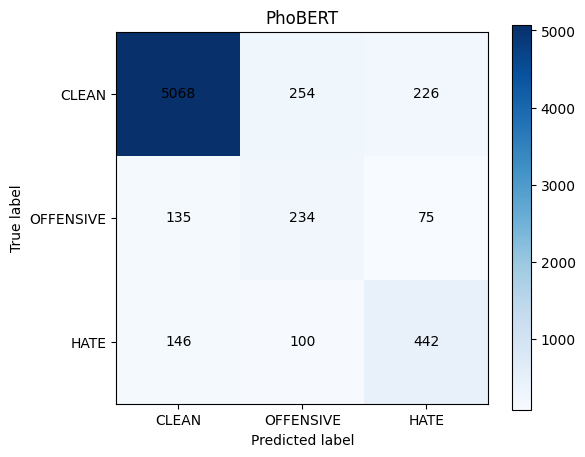

In [16]:
# ve confusion matrix cua phobert
cm = confusion_matrix(result_df[LABEL_COL], result_df["phobert_pred"], labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_yticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("PhoBERT")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im)
os.makedirs(FIGURE_DIR, exist_ok=True)
fig.savefig(os.path.join(FIGURE_DIR, "phobert_confusion_matrix_recheck.png"), dpi=300, bbox_inches="tight")
plt.show()
